# pyGIMLi(empymod)

v5: add reasonable noise on complex component, implement inversion for real component only and amplitude only, try for having smaller depths so that amplitudes are not that different

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import pygimli
import empymod

rng = np.random.default_rng(seed=0) #seed guarantees the same noise is reproduced each time, can be adapted with different numbers to test different noise

## Create survey, model, and data

In [5]:
# Survey: Offsets and Frequencies
rec_offsets = np.array([5, 15, 25])
frequencies = [10]

#Resistivity definition
base_res = 35 #Ohmm
anom_res = 20 #Ohmm

# Model depths and resistivities
depth = [0, 11, 19]
mtrue = [2e14, base_res, anom_res, base_res]
m0 = [2e14, base_res, base_res, base_res]

# Collect input parameters
inp = {
    'src': [-40, -20, 0, 0, 0, 0],
    'rec': [rec_offsets*0, rec_offsets*0, rec_offsets, 0, 90],
    'depth': depth,
    'freqtime': frequencies,
    'verb': 1,
}

# Create observed data and background == start model data
dobs = empymod.bipole(res=mtrue, **inp)
d0 = empymod.bipole(res=m0, **inp)

### Add noise to `dobs`
=> The following cell should go into `empymod`, or use `emg3d`, where it is already implemented

In [9]:
noise_floor = 1e-15
relative_error = 0.01
mean_noise = 0.0

# Exclude data below half the noise_floor
cut_data = abs(dobs) < (noise_floor / 2)
dobs[cut_data] = np.nan + 1j*np.nan
d0[cut_data] = np.nan + 1j*np.nan

# Add random white noise to dobs
std_dev_real = np.sqrt(noise_floor**2 + np.abs(relative_error*dobs.real)**2)
std_dev_imag = np.sqrt(noise_floor**2 + np.abs(relative_error*dobs.imag)**2)
noise_real = rng.normal(loc=0, scale=std_dev_real, size = dobs.shape)
noise_imag = rng.normal(loc=0, scale=std_dev_imag, size = dobs.shape)
noise = noise_real + 1j*noise_imag
dobs += noise

Shape of noise:  (3,)
Mean noise:  1.0302079297545755e-06
Minimum noise:  (-8.905083789819816e-07+3.391448981804686e-11j)
Maximum noise:  (1.28589253679986e-06-4.358777243744445e-10j)


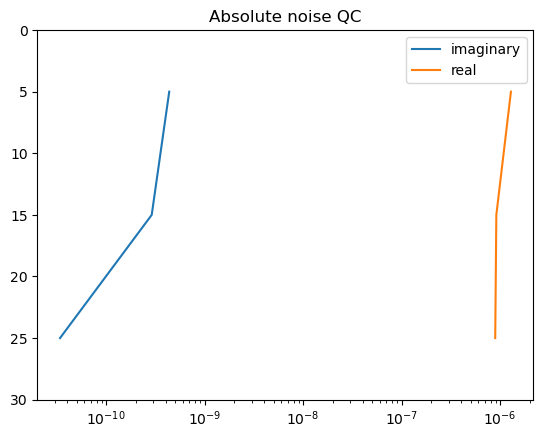

In [12]:
#QC the noise

print("Shape of noise: ", np.shape(noise))
print("Mean noise: ", np.mean(np.abs(noise)))
print("Minimum noise: ", np.min(noise))
print("Maximum noise: ", np.max(noise))

plt.title('Absolute noise QC')
plt.plot(abs(np.imag(noise)), rec_offsets, label='imaginary')
plt.plot(abs(np.real(noise)), rec_offsets, label='real')
plt.ylim([30, 0])
#plt.xlim([1e-10, 4e-8])
plt.xscale('log')
plt.legend()

## QC model and data

C:\Users\suzannevannoor\AppData\Local\Temp\ipykernel_10024\2517416492.py:39: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale('log')


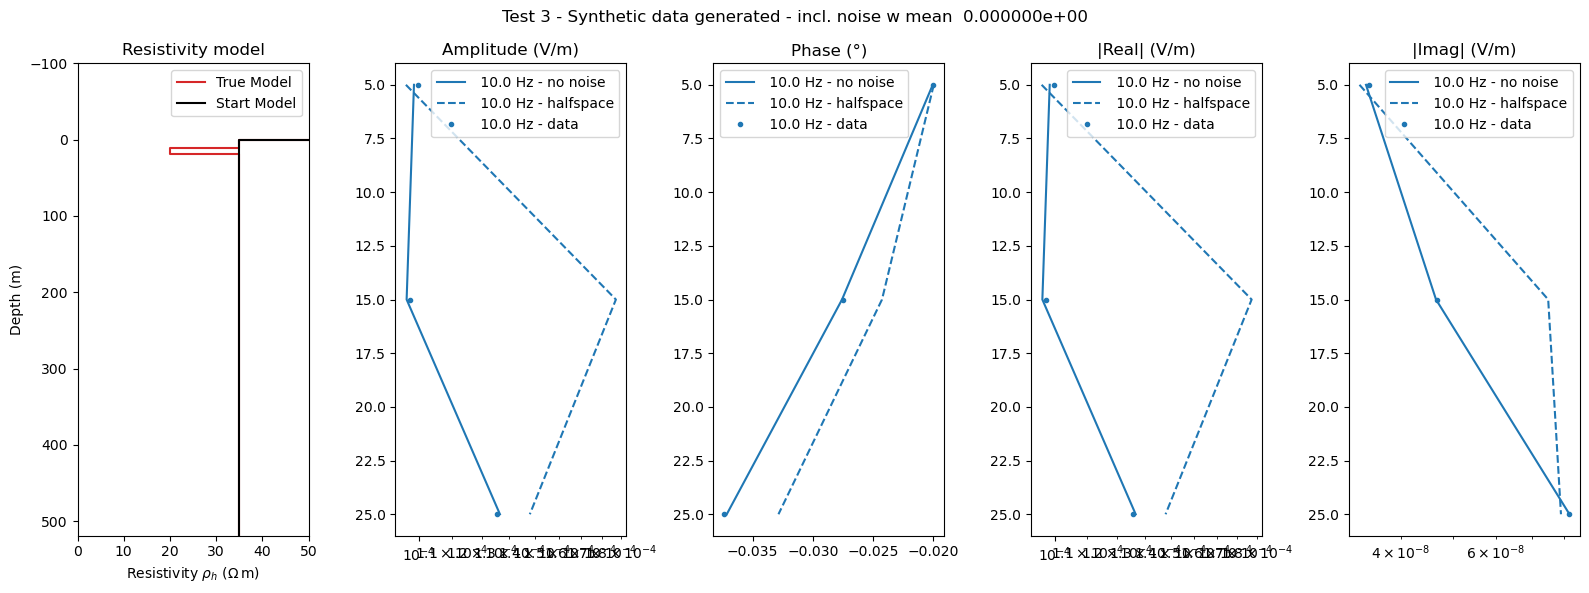

In [13]:
# Plot it
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(16, 6), tight_layout=True)
axes = [ax1, ax2, ax3, ax4, ax5]

p_mtrue = np.repeat(mtrue, 2)
p_m0 = np.repeat(m0, 2)
p_depth = np.r_[-100, np.repeat(depth, 2), 3000]

# Plot Resistivities
ax1.set_title('Resistivity model')
ax1.plot(p_mtrue, p_depth, 'C3', label="True Model")
ax1.plot(p_m0, p_depth, 'k', label="Start Model")
#ax1.set_xscale('log')
ax1.set_xlim([0, 50])
ax1.set_ylim([depth[-1]+500, depth[0]-100])
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Resistivity $\rho_h\ (\Omega\,\rm{m})$')
ax1.legend()

#Plot measured data
labels = ['Amplitude (V/m)', 'Phase (°)', '|Real| (V/m)', '|Imag| (V/m)']
data_obs = [dobs.amp(), dobs.pha(deg=True), abs(dobs.real), abs(dobs.imag)]
data0 = [(dobs-noise).amp(), (dobs-noise).pha(deg=True), abs((dobs-noise).real), abs((dobs-noise).imag)]
data00 = [d0.amp(), d0.pha(deg=True), abs(d0.real), abs(d0.imag)]
fig.suptitle("Test 3 - Synthetic data generated - incl. noise w mean "+f"{mean_noise: 3e}")
for j in np.arange(len(labels)):
    ax = axes[j+1]
    ax.set_title(labels[j])
    for i, f in enumerate(frequencies):
        if len(frequencies) == 1:
            ax.plot(data0[j][:], rec_offsets, 'C'+str(i)+'-', label = f"{f: 2.1f} Hz - no noise")
            ax.plot(data00[j][:], rec_offsets, 'C'+str(i)+'--', label = f"{f: 2.1f} Hz - halfspace")
            ax.plot(data_obs[j][:], rec_offsets, 'C'+str(i)+'.', label=f"{f: 2.1f} Hz - data")
        else:
            ax.plot(data0[j][i,:], rec_offsets, 'C'+str(i)+'-', label = f"{f: 2.1f} Hz - no noise")
            ax.plot(data00[j][i,:], rec_offsets, 'C'+str(i)+'--', label = f"{f: 2.1f} Hz - halfspace")
            ax.plot(data_obs[j][i,:], rec_offsets, 'C'+str(i)+'.', label=f"{f: 2.1f} Hz - data")
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.legend()
    #ax.set_xlim([-1e-7, 1e-7])

ax3.set_xscale('linear')

#It can be seen that the imaginary noise is very high compared to the signal difference

## Forward Kernel and modified Inversion class
=> The following cell should go into `empymod.inv.pygimli`

In [25]:
class Kernel(pygimli.Modelling):
    
    def __init__(self, input_map, routine=empymod.bipole):
        """Initialize the model."""
        super().__init__()

        # Store inputs
        self.input_map = input_map
        self.routine = routine
        
    def response(self, x):
        """Forward response.""" 
        #print('problem 0')   

        # Compute responses
        em = self.routine(**self.input_map(x))
        
        # Ravel output, taking care of complex values
        em = np.r_[em.ravel().real, em.ravel().imag if np.iscomplexobj(em) else []]

        # Return required data
        return em if not hasattr(self, 'indices') else em[self.indices]
    
    def createStartModel(self, dataVals=None):
        """Overwrite default method with an Error.""" 
        raise NotImplementedError("Start Model must be provided.")

class Inversion(pygimli.Inversion):
    
    def run(self, dataVals, errorVals=None, **kwargs):

        # Store the mesh (pseudo)
        if "startModel" in kwargs:
            n_model = len(np.atleast_1d(kwargs["startModel"]))
        else:
            n_model = len(self.startModel)
        self.fop.mesh1d = pygimli.meshtools.createMesh1D(n_model)
        self.fop.setMesh(self.fop.mesh1d)

        # Error: Same as in original function, but taking care of complex data
        if errorVals is None:  # use absoluteError and/or relativeError instead
            absErr = kwargs.pop("absoluteError", 0)
            relErr = kwargs.pop("relativeError",
                                0.01 if np.allclose(absErr, 0) else 0)
            errorVals = abs(absErr / np.asarray(abs(dataVals))) + relErr

        if isinstance(errorVals, (float, int)):
            errorVals = np.ones_like(dataVals.real) * errorVals
        
        # Ravel data and decompose complex data
        d_size = dataVals.size
        d_shape = dataVals.shape
        is_complex = False
        if np.iscomplexobj(dataVals):
            is_complex = True
            d_size *= 2
        dataVals = np.r_[dataVals.ravel().real, dataVals.ravel().imag if is_complex else []]
        errorVals = np.r_[errorVals.ravel().real, errorVals.ravel().imag if is_complex else []]

        # Limit to finite values
        if np.any(~np.isfinite(dataVals)):
            self.fop.indices = np.isfinite(dataVals)
            dataVals = dataVals[self.fop.indices]
            errorVals = errorVals[self.fop.indices]

        # Run the inversion
        model = super().run(dataVals=dataVals, errorVals=errorVals, **kwargs)

        # Reshape data           
        if hasattr(self.fop, 'indices'):
            out = np.ones(d_size)*np.nan
            out[self.fop.indices] = np.array(self.response)
        else:
            out = np.array(self.response)
        if is_complex:
            out = out[:d_size//2] + 1j*out[d_size//2:]               
        response = empymod.EMArray(np.reshape(out, d_shape))

        # Return mapped parameters and response
        return self.fop.input_map(model), response
    
    

## Inversion

The objective function is calculated like:

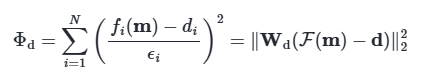

with f_i(m) the modelled data (forward response at the data point), d_i the data, eps_i the error, N the amount of data points. An expression in terms of W_d is derived with W_d being a data weighting matrix containing the inverse data errors and F(m) the forward model response vector.

Once the objective function is determined, we determine the gradient. This is done using Gauss-Newtonian method in our case, which works by solving the following formula using a least-squares solver:

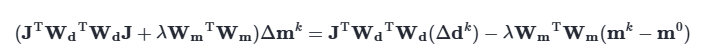

This allows us to find delta-m which indicates the direction of the model update. **But it should be noted that a transformation by scalar tau is needed to determine the actual step increase.** This is found in PyGIMLi by doing a line search.

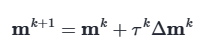



In [17]:
%%time

def input_map(x, inp=inp):
    """Map the inversion parameter to modelling parameters."""
    # Could be res, aniso, depth, a mixture of it, ...
    inp['res'] =  np.r_[2e14, x, base_res]
    return inp

fop = Kernel(input_map, empymod.bipole)
inv = Inversion(fop=fop)

# Not Sure Yet How To Use These (comment from Dieter)
#inv.dataTrans = pygimli.trans.TransSymLog(1e-20)
#inv.transModel = pygimli.trans.TransLog(0.1) # > 1 Ohmm

#inv.modelTrans = 'log'

lam = 1 #somehow using inv.lam to set/retrieve lambda gives the wrong lambda even though the inversion correctly uses lambda given

out, response = inv.run(
    dataVals=dobs,
    absoluteError=std_dev_real+1j*std_dev_imag,
    #relativeError=0.01,
    startModel=m0[1:-1],
    verbose = True,
    dPhi=2, #Sets percentage change of objective function at which the inversion should stop
    #max_iter = 30,
    lam=lam
)

# Get inversion result from parameter dict
# Could be res, aniso, depth, ...
minv = out['res']

13/07/26 - 17:01:59 - pyGIMLi - WARNING - Found zero error values. Setting them to fallback value of 1
13/07/26 - 17:01:59 - pyGIMLi - INFO - Starting inversion.


[0.00987128 0.00990618 0.01007087 0.         0.         0.        ]
fop: <__main__.Kernel object at 0x000002CADB0BF290>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): -8.2e-08/1.3e-04
min/max (error): 0%/1.01%
min/max (start model): 35/35
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =     inf
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   44.26 (dPhi = nan%) lam: 1.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    0.32 (dPhi = nan%) lam: 1.0


################################################################################
#                  Abort criterion reached: chi² <= 1 (0.32)                   #
################################################################################
CPU times: total: 31.2 ms
Wall time: 28.4 ms


## Plot results

C:\Users\suzannevannoor\AppData\Local\Temp\ipykernel_10024\256523810.py:40: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale('log')


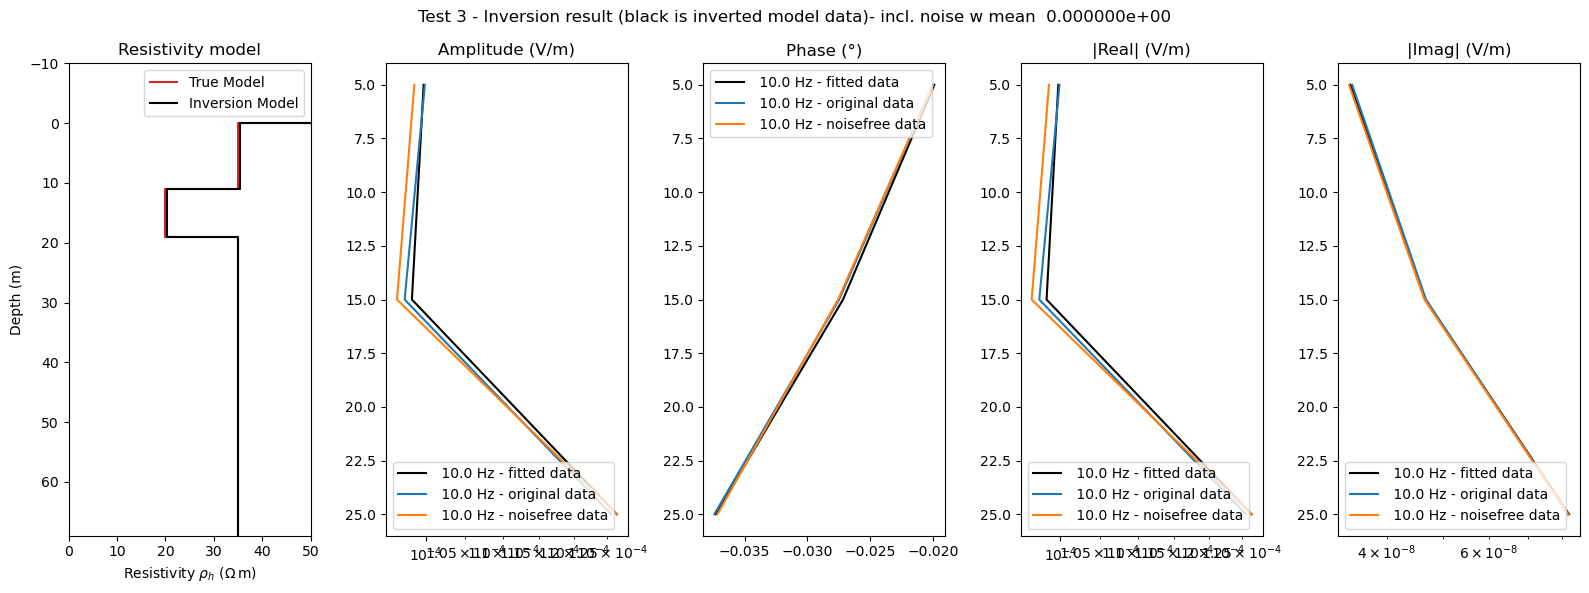

In [20]:
# Plot it
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(16, 6), tight_layout=True)
axes = [ax1, ax2, ax3, ax4, ax5]

p_mtrue = np.repeat(mtrue, 2)
p_m0 = np.repeat(m0, 2)
p_depth = np.r_[-10, np.repeat(depth, 2), 300]
p_minv = np.repeat(minv, 2)

# Plot Resistivities
ax1.set_title('Resistivity model')
ax1.plot(p_mtrue, p_depth, 'C3', label="True Model")
ax1.plot(p_minv, p_depth, 'k', label="Inversion Model")
#ax1.set_xscale('log')
ax1.set_xlim([0, 50])
ax1.set_ylim([depth[-1]+50, depth[0]-10])
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Resistivity $\rho_h\ (\Omega\,\rm{m})$')
ax1.legend()

#Plot measured data
labels = ['Amplitude (V/m)', 'Phase (°)', '|Real| (V/m)', '|Imag| (V/m)']
data_obs = [dobs.amp(), dobs.pha(deg=True), abs(dobs.real), abs(dobs.imag)]
data0 = [(dobs-noise).amp(), (dobs-noise).pha(deg=True), abs((dobs-noise).real), abs((dobs-noise).imag)]
data_inv = [response.amp(), response.pha(deg=True), abs(response.real), abs(response.imag)]
fig.suptitle("Test 3 - Inversion result (black is inverted model data)- incl. noise w mean "+f"{mean_noise: 3e}")
for j in np.arange(len(labels)):
    ax = axes[j+1]
    ax.set_title(labels[j])
    for i, f in enumerate(frequencies):
        if len(frequencies) == 1:
            ax.plot(data_inv[j][:], rec_offsets, 'k', label=f"{f: 2.1f} Hz - fitted data")
            ax.plot(data_obs[j][:], rec_offsets, label=f"{f: 2.1f} Hz - original data")
            ax.plot(data0[j][:], rec_offsets, label=f"{f: 2.1f} Hz - noisefree data")
        else:
            ax.plot(data_inv[j][i,:], rec_offsets, 'k', label=f"{f: 2.1f} Hz - fitted data")
            ax.plot(data_obs[j][i,:], rec_offsets, label= f"{f: 2.1f} Hz - original data")
            ax.plot(data0[j][i,:], rec_offsets, label=f"{f: 2.1f} Hz - noisefree data")
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.legend()

ax3.set_xscale('linear')

## Plot inversion steps taken

In [1]:
#Extract details from the inversion process

#print("Lambda last iteration: ", inv.lam, " (it can change during inversion)")
model_history = inv.modelHistory
chi2_history = inv.chi2History
jacobians = np.array(inv.fop.jacobian())
print("Chi2 history: ", chi2_history) #QC that chi2 history are the same as verbose output

absrms_history = []
absrms_real_history = []
absrms_complex_history = []
dobs_gimli = np.r_[dobs.ravel().real, dobs.ravel().imag] #Convert observed data to same shape as PyGIMLi outputs

#Back-calculate the RMS values of the datas
#Back-calculate the data-part of the objective function using the kernels defined before and the model history that was saved
phi_history = []
phi_data_history = []
for i in np.arange(len(model_history)):
    data = np.array(fop.response(model_history[i]))
    absrms_history.append(np.sqrt(np.mean(dobs_gimli-data)**2))
    absrms_real_history.append(np.sqrt(np.mean(dobs_gimli[:int(len(data)/2)]-data[:int(len(data)/2)])**2))
    absrms_complex_history.append(np.sqrt(np.mean(dobs_gimli[int(len(data)/2):]-data[int(len(data)/2):])**2))
    phi_history.append(inv.phi(response=fop.response(model_history[i])))
    phi_data_history.append(inv.phiData(response=fop.response(model_history[i]))) #This way we exclude the effect of regularization
#print(phi_history)
#print(phi_data_history)
# DONT TRUST PHI DATA ANYMORE BECAUSE OF SCALING

#Calculate the deltaPhi and QC that these are the same as the verbose inversion output
phi_delta_history = []
for i in np.arange(1, len(phi_data_history)):
    phi_delta_history.append((phi_data_history[i]-phi_data_history[i-1])/phi_data_history[i-1])
print("Phi_delta history: ", phi_delta_history)

NameError: name 'inv' is not defined

[inf, inf, inf]


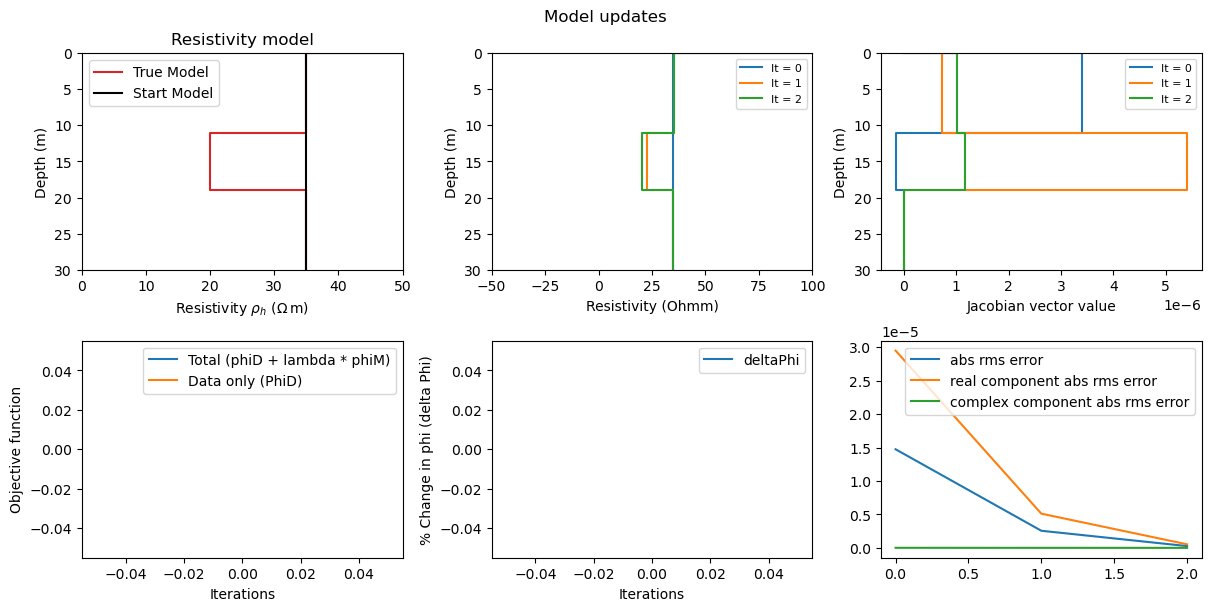

In [24]:
fig, ((ax0, ax1, ax2), (ax3, ax4, ax5)) = plt.subplots(2,3, figsize=(12,6), constrained_layout=True)
fig.suptitle('Model updates')
ax1.set_xlabel('Resistivity (Ohmm)')
ax1.set_ylabel('Depth (m)')
ax2.set_xlabel('Jacobian vector value')
ax2.set_ylabel('Depth (m)')
ax3.set_xlabel('Iterations')
ax3.set_ylabel('Objective function')
ax4.set_xlabel('Iterations')
ax4.set_ylabel('% Change in phi (delta Phi)')

ax0.set_title('Resistivity model')
ax0.plot(p_mtrue, p_depth, 'C3', label="True Model")
ax0.plot(p_m0, p_depth, 'k', label="Start Model")
ax0.set_xlim([0, 50])
ax0.set_ylim([30, 0])
ax0.set_ylabel('Depth (m)')
ax0.set_xlabel(r'Resistivity $\rho_h\ (\Omega\,\rm{m})$')
ax0.legend()

np.set_printoptions(precision=2)

for i, model in enumerate(model_history):
    data = np.array(fop.response(model))
    model_to_plot = np.concatenate([[2e14], np.repeat(model,2), [base_res, base_res]])
    jac_to_plot = np.concatenate([[0], np.repeat(jacobians[i],2), [0,0]])
    ax1.plot(model_to_plot, np.concatenate([np.repeat(depth,2), [500]]), label='It = '+str(i))
    ax2.plot(jac_to_plot, np.concatenate([np.repeat(depth,2), [500]]), label='It = '+str(i))
    #print(f"Iteration {i}: Model = {np.array(model)}")
    #print(f"Jacobian = {np.array(jacobians[i], dtype=float)}")

ax3.plot(np.arange(len(phi_history)), phi_history, label = 'Total (phiD + lambda * phiM)')
ax3.plot(np.arange(len(phi_history)), phi_data_history, label = 'Data only (PhiD)')
ax4.plot(np.arange(1,len(phi_history)), np.abs(phi_delta_history), label = 'deltaPhi')
ax5.plot(np.arange(len(phi_history)), absrms_history, label = 'abs rms error')
ax5.plot(np.arange(len(phi_history)), absrms_real_history, label = 'real component abs rms error')
ax5.plot(np.arange(len(phi_history)), absrms_complex_history, label = 'complex component abs rms error')

print(phi_data_history)
ax1.set_ylim([30,0])
ax2.set_ylim([30, 0])
#ax.set_xscale('log')
ax1.set_xlim([-50, 100])
ax1.legend(fontsize=8)
ax2.legend(fontsize=8)
ax3.legend()
ax4.legend()
ax5.legend()

## Assess single iterations

1
[2.00e+14 2.00e+14 1.36e+01 1.36e+01 3.75e+01 3.75e+01 3.50e+01 3.50e+01]


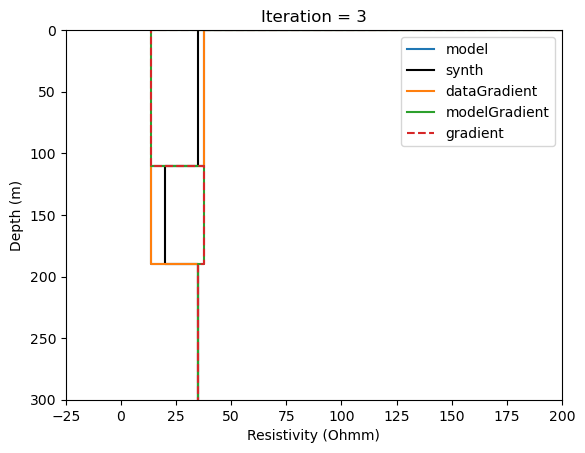

In [24]:
#Zoom into whats happening with a single iteration
#Using pyGIMLi example code: https://www.pygimli.org/user-guide/inversion/
#NOT SURE HOW THIS IS WORKING WITH PARAMETER TRANSFORMATION

iteration = 3
model = model_history[iteration]

p_mtrue = np.repeat(mtrue, 2)
p_m0 = np.repeat(m0, 2)
p_depth = np.r_[-100, np.repeat(depth, 2), 300]
p_minv = np.repeat(np.concatenate(([2e14], model, [base_res])), 2)

dg = np.repeat(np.concatenate(([0],-inv.dataGradient(), [0])), 2)#-inv.dataGradient()
print(lam)
mg = np.repeat(np.concatenate(([0], -inv.modelGradient() * lam, [0])), 2)#-inv.modelGradient() * lam
plt.plot(p_minv, p_depth, label="model")
plt.plot(p_mtrue, p_depth, label="synth", color="black")
plt.plot(np.exp(dg)*p_minv, p_depth, label="dataGradient")
plt.plot(np.exp(mg)*p_minv, p_depth, label="modelGradient")
plt.plot(np.exp(mg+dg)*p_minv, p_depth, ls="--", label="gradient")
plt.ylim([300,0])
plt.xlim([-25, 200])
plt.ylabel('Depth (m)')
plt.xlabel('Resistivity (Ohmm)')
plt.xlim
plt.legend()
plt.title('Iteration = '+str(iteration))

print(np.exp(mg)*p_minv)

#model is overlapping with data gradient

In [8]:
empymod.Report(['pyGIMLi', 'pgcore'])

--------------------------------------------------------------------------------
  Date: Mon Jun 01 11:50:33 2026 UTC

                OS : Windows (10 10.0.26100 SP0 Multiprocessor Free)
            CPU(s) : 14
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.4 GiB
       Environment : Jupyter

  Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00)
  [MSC v.1944 64 bit (AMD64)]

           pyGIMLi : 1.5.5
            pgcore : 1.5.0
             numpy : 1.26.4
             scipy : 1.14.1
             numba : 0.65.1
           empymod : 2.5.4
            libdlf : 0.3.0
           IPython : 9.10.0
        matplotlib : 3.10.9
--------------------------------------------------------------------------------

In [ ]:
def __init__(self, fop=None, inv=None, **kwargs):
        """Initialize an Inversion instance."""
        super().__init__(fop=fop, inv=inv, **kwargs)
        self._postStep = _post_step

def _post_step(n, inv):
        """Print some values for each iteration. Written for use with emg3d now adapted to use with empymod.
        https://github.com/emsig/emg3d/blob/inv-pygimli/emg3d/inversion/pygimli.py#L294-L297"""
        #sim = inv.fop.simulation

        # Print info
        phi = inv.inv.getPhi()
        if n == 0:
            pygimli.info(
                f"{75*'='}\n{39*' '}"
                " it   F(m)         χ²          λ         ϕᵈ         ϕᵐ"
                f"   ϕ=ϕᵈ+λϕᵐ   Δϕ (%)\n{39*' '}{75*'-'}"
            )
            deltaphi = 0
            #sim.invinfo = {}

        else:
            deltaphi = (1-phi/inv.lastphi)*100
        inv.lastphi = phi
        pygimli.info(
            f"{n:3d}"
            f"{_multiprocessing.process_map.count:7d} "
            f"{_round_format(inv.inv.chi2())} "
            f"{_round_format(inv.inv.getLambda())} "
            f"{_round_format(inv.inv.getPhiD())} "
            f"{_round_format(inv.inv.getPhiM())} "
            f"{_round_format(phi)}"
            f"{deltaphi:9.2f}"
        )

        # Store data TODO store everything required to reproduce or restart inv
        #sim.survey.data[f"it{n}"] = sim.survey.data.synthetic
        # TODO store data and model as gimli vectors; requires region info
        #model = inv.fop.simulation.model.copy()
        model = inv._start
        model.property_x = inv.fop.model2emg3d(inv.model)
        sim.invinfo[n] = {
            'model': model,
            'chi2': inv.inv.chi2(),
            'phi': phi,
            'phi_d': inv.inv.getPhiD(),
            'phi_m': inv.inv.getPhiM(),
            'phi_delta': deltaphi,
            'count': _multiprocessing.process_map.count,
            'lambda': inv.inv.getLambda(),
            'time': sim.timer.elapsed,
        }
        if sim.name:
            io.save(
                f"{sim.name}.h5",
                simulation=sim.to_dict(what='plain'),
                invinfo=sim.invinfo,
                verb=0,
            )

        # Reset counter
        _multiprocessing.process_map.count = 0